# Plot figures relative to town masks

### Packages and Directories

In [129]:
# --- Imports ---
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.distributed import Client, LocalCluster
from scipy.interpolate import griddata
from statsmodels.stats.multitest import fdrcorrection
import calendar
from datetime import datetime, timedelta
import cftime

from scipy import ndimage

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Custom Functions ---
# sys.path.append('/home/portal/script/python/precip_Cristina/')                    # tintin
sys.path.append('/home/alice/Desktop/work/git/myISACcode/python/precip_Cristina')   # alice
import functions_analogues_PrMax as fanPM
import functions_analogues_LUCAFAMOSS as fan

In [130]:
# Define directories for data and figures
# # tintin
# CERRA_dir = '/work_big/users/clima/portal/CERRA/'
# ERA5_dir = '/work_big/users/clima/portal/ERA5/'
# CRCM5_dir = '/work_big/users/clima/portal/CRCM5-LE/'
# fig_dir = '/home/portal/figures/analogues/'

# alice
CERRA_dir = '/media/alice/Crucial X9/portal/data_CNR/CERRA/'
ERA5_dir = '/media/alice/Crucial X9/portal/data_CNR/ERA5/'
CRCM5_dir = '/media/alice/Crucial X9/portal/data_CNR/CRCM5-LE/'
fig_dir = '/home/alice/Desktop/CNR/ENCIRCLE/materiale_alice/figures/analogues/poster/'
diff_dir = './analogue_data/analogue_differences/'
pr_mask_dir = './analogue_data/pr_in_mask/'

### Parameters

In [131]:
# Variable
var_analogues = 'psl-zg500-std'  # Variable used to find the analogues, e.g. 'psl' for sea level pressure
var_BAM = 'psl'                  # Variable used for the BAM search

# Quantile and analogue number
qtl_LE = 0.99    # 0.99 (18 anaologues) or 0.999 (2 analogues)
if qtl_LE*100 % 1 == 0:
    qtl_LE_str = f"{int(qtl_LE*100)}pct"
    no_analogues = 18
else:
    qtl_LE_str = f"{qtl_LE*100:.1f}pct"
    no_analogues = 2

# Number of ensemble members
no_membs = 49

# List of members
list_membs = [name for name in os.listdir(CRCM5_dir + 'psl') if os.path.isdir(os.path.join(CRCM5_dir + 'psl', name))]
list_membs = sorted(list_membs)[:no_membs]  # Select the first 'no_membs' members


In [132]:
# Event
lselect = 'alertregions'  # 'Italy' or 'wide-region' or 'alert-regions'
no_node = 6
no_event = 19
event_origin = 'CRCM5-LE'  # 'ERA5' or 'CRCM5-LE'
str_event_ERA5 = f'node{no_node}-extreme{no_event}-{lselect}'  # 'Italy' or 'wide-region' or 'alert-regions'
str_event_BAM = f'BAM-node{no_node}-extreme{no_event}-{lselect}'  # 'Italy' or 'wide-region' or 'alert-regions'

# ERA5
df_events = pd.read_excel(CERRA_dir+'events_cum_on_above99_alertregions_CERRA.xlsx', sheet_name=no_node-1)
time_ERA5event = df_events['Time'].iloc[no_event-1] + pd.Timedelta('12h')
doy_ERA5event =  time_ERA5event.timetuple().tm_yday

# BAM
BAM_info, BAM_index = fanPM.get_best_model_analogue_info(no_node, no_event, var_BAM)
time = datetime.strptime(BAM_info['date'][BAM_index], "%Y-%m-%d")
time_BAMevent = cftime.DatetimeNoLeap(time.year, time.month, time.day, hour=0, minute=0, second=0)
doy_BAMevent = time_BAMevent.timetuple().tm_yday
member_BAMevent = BAM_info['member'][BAM_index]

# Define lon-lat box of event
box_event = fanPM.box_event_PrMax_alertregions(no_node,no_event)

# Defines the months for analogue selection
# ERA5
month_ERA5event = time_ERA5event.month
months_sel_ERA5 = [month_ERA5event-1, month_ERA5event, month_ERA5event+1]
month_names_ERA5 = [calendar.month_abbr[month] for month in months_sel_ERA5]
str_months_ERA5 = ''.join([name[0] for name in month_names_ERA5])
# BAM
month_BAMevent = time_BAMevent.month
months_sel_BAM = [month_BAMevent-1, month_BAMevent, month_BAMevent+1]
month_names_BAM = [calendar.month_abbr[month] for month in months_sel_BAM]
str_months_BAM = ''.join([name[0] for name in month_names_BAM])



### Upload analogue mean in different epochs

In [133]:
# Variable
varname = 'pr'
factor = 3600

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)


In [134]:
# Upload analogue data
list_ds = []  # List to store difference datasets
for i in range(no_epochs):
    year_range = list_year_ranges[i]
    str_year_range = "-".join(str(x) for x in year_range)
    suffix_file = f"{varname}_{str_event_BAM}_{qtl_LE_str}_{str_year_range}_CRCM5_{no_membs}membs.nc"

    # Load analogue anomalies
    file = f'{diff_dir}analogues-{var_analogues}_{suffix_file}'
    if not os.path.exists(file):
        print(f'File {file} does not exist. Skipping epoch {i+1}.')
        continue
    ds = xr.open_dataset(file)
    list_ds.append(ds)

In [135]:
land_mask = fanPM.create_land_mask(list_ds[0].lon.values, list_ds[0].lat.values)
town_names, town_coords, town_masks, town_masks_expanded = fanPM.create_town_mask(list_ds[0].lon.values, list_ds[0].lat.values, no_node, no_event)

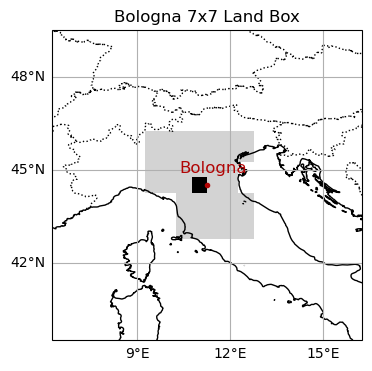

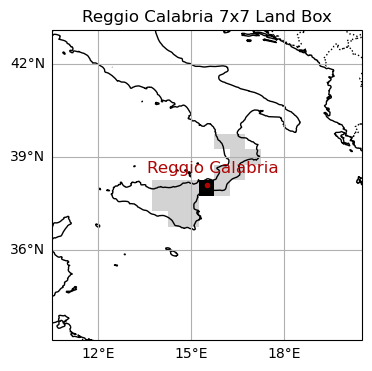

In [136]:
# Cartopy map of mask
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.ticker as mticker

for itown in range(len(town_names)):

    box_town = [town_coords[itown][1]-5, town_coords[itown][1]+5, town_coords[itown][0]-5, town_coords[itown][0]+5]  # [lon_min, lon_max, lat_min, lat_max]
    
    fig, ax = plt.subplots(figsize=(4, 5), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent(box_town, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE)
    gl = ax.gridlines(draw_labels=True)# every 3 degrees
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 3))
    gl.ylocator = mticker.FixedLocator(np.arange(-90, 90, 3))
    gl.top_labels = False
    gl.right_labels = False
    
    mask_all_expanded = np.zeros_like(land_mask.values, dtype=int)
    mask_all_towns = np.zeros_like(land_mask.values, dtype=int)
    # for itown in range(len(town_names)):
    mask_all_towns += town_masks[itown].astype(int)  # Add the original town mask
    mask_all_expanded += town_masks_expanded[itown].astype(int)  # Add the expanded town mask
    mask_all_expanded *= ((land_mask+mask_all_towns)>0).astype(int)  # Apply land mask to the combined town mask
    cmap_expanded = ListedColormap(['white', 'lightgrey']) # ListedColormap(['white', 'lightgrey', 'grey'])
    cmap_town = ListedColormap(['none', 'black'])
    ax.pcolormesh(mask_all_expanded.lon.values, mask_all_expanded.lat.values, mask_all_expanded.values, transform=ccrs.PlateCarree(), cmap=cmap_expanded) #, colors=['w', 'lightgrey', 'grey']levels=[-0.5,0.5,1.5,2.5],
    ax.pcolormesh(mask_all_towns.lon.values, mask_all_towns.lat.values, mask_all_towns.values, transform=ccrs.PlateCarree(), cmap=cmap_town) #, colors=['none', 'black'], levels=[-0.5,0.5,1.5],
    
    # for itown in range(len(town_names)):
    ax.plot(town_coords[itown][1], town_coords[itown][0], marker='o', color="#B10505", markersize=3, transform=ccrs.PlateCarree())
    ax.text(town_coords[itown][1]+0.2, town_coords[itown][0]+0.4, town_names[itown], fontsize=12, color="#B10505", ha='center', transform=ccrs.PlateCarree())
    plt.title(f'{town_names[itown]} 7x7 Land Box')
    plt.show()
    fig.savefig(fig_dir + f'{town_names[itown]}_mask_7x7grid-and-land.png', dpi=300, bbox_inches='tight')
    fig.savefig(fig_dir + f'{town_names[itown]}_mask_7x7grid-and-land.pdf', bbox_inches='tight')

### Upload town data

In [137]:
# Parameters
# Variable
varname = 'pr'
factor = 3600

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)
names_year_ranges = ["PAST", "PRESENT", "FUTURE"]
ind_1 = 0 # index epoch 1
ind_2 = 1 # index epoch 2

# Significance test
stat_test = 'tW'  # 'KS' for Kolmogorov-Smirnov test, tW for Welch's t-test, AD for Anderson-Darling test, CvM for Cramér-von Mises test
stat, stat_func = fanPM.get_stat_test(stat_test)

# List of ensemble sizes (by no members considered)
list_size_ens = [1, 2, 5, 10, 49]
str_size_ens = ''
for se in list_size_ens:
    str_size_ens += f'{se}-'
str_size_ens = str_size_ens[:-1] + 'membs'
print(str_size_ens)

# Towns
no_towns = len(town_names)
no_town_var = 3


1-2-5-10-49membs


In [138]:
# BAM regional mean precipitation
BAM_info, BAM_index = fanPM.get_best_model_analogue_info(no_node, no_event, var_BAM)

# Upload analogue data for mean precipitation in BAM mask per ensemble member
no_size = len(list_size_ens)
list_pr_town = []  # List to store mean precipitation for each ensemble member
list_pr_town_bysize = []  # List to store mean precipitation for different ensemble sizes
list_str_year_range = []
for j in range(no_epochs):
    year_range = list_year_ranges[j]
    str_year_range = "-".join(str(x) for x in year_range)
    list_str_year_range.append(str_year_range)
    # Load analogue values
    pr_town_epoch = np.ones((no_membs, no_towns, no_town_var, no_analogues)) * np.nan
    for im, memb in enumerate(list_membs):
        for itown in range(no_towns):
            file = f'{pr_mask_dir}towns/analogues-{var_analogues}_{town_names[itown]}-{varname}_{str_event_BAM}_{qtl_LE_str}_{str_year_range}_CRCM5_{memb}.nc'
            if not os.path.exists(file):
                print(f'File {file} does not exist. Skipping epoch {j+1}.')
                continue
            len_analogues = xr.open_dataset(file)['pr_town'].shape[0]
            pr_town_epoch[im, itown, 0, :len_analogues] = xr.open_dataset(file)['pr_town'].values * factor
            pr_town_epoch[im, itown, 1, :len_analogues] = xr.open_dataset(file)['pr_town_7x7'].values * factor
            pr_town_epoch[im, itown, 2, :len_analogues] = xr.open_dataset(file)['pr_town_7x7_land'].values * factor
    list_pr_town.append(pr_town_epoch)

# Results of sign and significance test
no_boot = 1000
sign_town_size = np.zeros((2, no_size-1, no_towns, no_town_var))
significance_town_size = np.zeros((2, no_size-1, no_towns, no_town_var)) # 2 for binary boolean options
# RMSE
rmse_bysize = []
# Reconstruct samples of different ensemble sizes
pr_town_size_byepoch = np.ones((no_epochs, no_size, no_boot, no_towns, no_town_var)) * np.nan
# Fill for full ensemble
for iepoch in range(no_epochs):
    pr_town_size_byepoch[iepoch, -1, :] = np.nanmean(list_pr_town[iepoch], axis=(0, 3))
diff_pastpres = pr_town_size_byepoch[1, -1, 0] - pr_town_size_byepoch[0, -1, 0]
diff_presfut = pr_town_size_byepoch[2, -1, 0] - pr_town_size_byepoch[1, -1, 0]
diff_pastfut = pr_town_size_byepoch[2, -1, 0] - pr_town_size_byepoch[0, -1, 0]
for isize in range(no_size-1):
    no_memb = list_size_ens[isize]
    for iboot in range(no_boot):
        random_indices = np.random.choice(no_membs, size=no_memb, replace=False)
        pr_town_irand = []
        for iepoch in range(no_epochs):
            pr_town_irand.append(list_pr_town[iepoch][random_indices])
            pr_town_size_byepoch[iepoch, isize, iboot] = np.nanmean(pr_town_irand[iepoch], axis=(0, 3))
        # sign and significance test
        for j in range(no_towns):
            for k in range(no_town_var):
                if pr_town_size_byepoch[ind_2, isize, iboot, j, k] > pr_town_size_byepoch[ind_1, isize, iboot, j, k]:
                    sign_town_size[0,isize,j,k] += 1
                    statistics = stat_func(pr_town_irand[ind_2][:, j, k].flatten(), pr_town_irand[ind_1][:, j, k].flatten())
                    significance_town_size[0,isize,j,k] += (statistics[1] < 0.05).astype(int)
                elif pr_town_size_byepoch[ind_2, isize, iboot, j, k] < pr_town_size_byepoch[ind_1, isize, iboot, j, k]:
                    sign_town_size[1,isize,j,k] += 1
                    statistics = stat_func(pr_town_irand[ind_2][:, j, k].flatten(), pr_town_irand[ind_1][:, j, k].flatten())
                    significance_town_size[1,isize,j,k] += (statistics[1] < 0.05).astype(int)
    # RMSE
    rmse_town = np.sqrt(np.nanmean( (pr_town_size_byepoch[ind_1,isize] - pr_town_size_byepoch[ind_1,-1,0])**2 + (pr_town_size_byepoch[ind_2,isize] - pr_town_size_byepoch[ind_2,-1,0])**2, axis=0))
    rmse_bysize.append(rmse_town)

# Finalise
# sign and significance
frac_sign = sign_town_size / no_boot
frac_significance = significance_town_size / no_boot
# rmse
rmse_bysize = np.array(rmse_bysize)

# save RMSE and true difference
for itown in range(no_towns):
    rmse = rmse_bysize[:,itown]
    frac_sign_tuples = [[tuple(frac_sign[:, i, itown, j]) for j in range(no_town_var)] for i in range(no_size-1)]
    frac_significance_tuples = [[tuple(frac_significance[:, i, itown, j]) for j in range(no_town_var)] for i in range(no_size-1)]
    if ind_1 == 0 and ind_2 == 1:
        diff = diff_pastpres
    elif ind_1 == 0 and ind_2 == 2:
        diff = diff_pastfut
    elif ind_1 == 1 and ind_2 == 2:
        diff = diff_presfut
    else:
        print("Invalid indices for epochs. Please set ind_1 and ind_2 to valid values.")
        continue
    # create a DataFrame to store the RMSE values
    df_rmse = pd.DataFrame(rmse, columns=['Town grid-point','Town 7x7 Box', 'Town 7x7 Land Box'])
    df_rmse['Ensemble Size'] = list_size_ens[:-1]
    df_rmse = df_rmse[['Ensemble Size', 'Town grid-point','Town 7x7 Box', 'Town 7x7 Land Box']]
    df_rmse.to_csv(f"{pr_mask_dir}towns/rmse_ens-mean_{town_names[itown]}-{varname}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{list_str_year_range[ind_1]}_{list_str_year_range[ind_2]}_CRCM5_{str_size_ens}.csv", index=False)
    # create a DataFrame to store the difference values
    df_diff = pd.DataFrame(diff[itown].reshape(1, no_town_var), columns=['Town grid-point','Town 7x7 Box', 'Town 7x7 Land Box'])
    df_diff.to_csv(f"{pr_mask_dir}towns/diff_ens-mean_{town_names[itown]}-{varname}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{list_str_year_range[ind_1]}_{list_str_year_range[ind_2]}_CRCM5_{no_membs}membs.csv", index=False)
    # create a DataFrame to store the sign and significance values
    df_sign = pd.DataFrame(frac_sign_tuples, columns=['Town grid-point','Town 7x7 Box', 'Town 7x7 Land Box'])
    df_sign['Ensemble Size'] = list_size_ens[:-1]
    df_sign = df_sign[['Ensemble Size', 'Town grid-point','Town 7x7 Box', 'Town 7x7 Land Box']]
    df_sign.to_csv(f"{pr_mask_dir}towns/sign-frac_ens-mean_{town_names[itown]}-{varname}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{list_str_year_range[ind_1]}_{list_str_year_range[ind_2]}_CRCM5_{str_size_ens}.csv", index=False)
    df_significance = pd.DataFrame(frac_significance_tuples, columns=['Town grid-point','Town 7x7 Box', 'Town 7x7 Land Box'])
    df_significance['Ensemble Size'] = list_size_ens[:-1]
    df_significance = df_significance[['Ensemble Size', 'Town grid-point','Town 7x7 Box', 'Town 7x7 Land Box']]
    df_significance.to_csv(f"{pr_mask_dir}towns/significance-frac_ens-mean_{town_names[itown]}-{varname}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{list_str_year_range[ind_1]}_{list_str_year_range[ind_2]}_CRCM5_{str_size_ens}.csv", index=False)

In [139]:
print(np.argmax(list_pr_town[1].mean(axis=3)[:,0,0]),np.max(list_pr_town[1].mean(axis=3)[:,0,0]))
print(list_pr_town[1].mean(axis=3)[19,0,2])

print(np.argmax(list_pr_town[0].mean(axis=3)[:,0,0]),np.max(list_pr_town[0].mean(axis=3)[:,0,0]))
print(list_pr_town[0].mean(axis=3)[31,0,2])


0 30.502169401556685
13.642378526441512
37 37.88392008013196
13.331692875040083


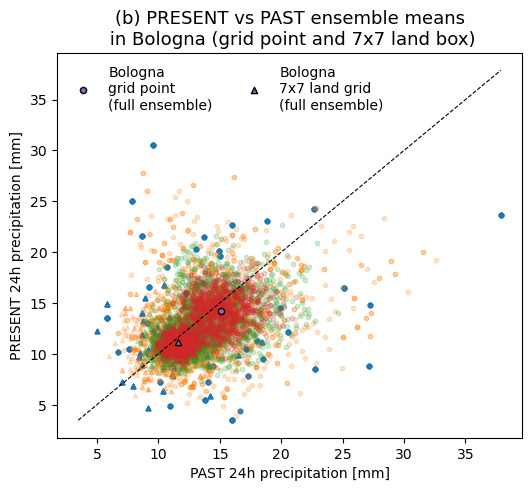

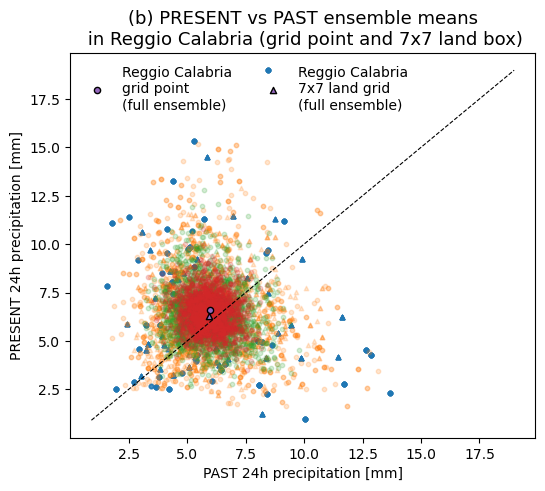

In [140]:
# Plot scatter plot of pr_2 vs pr_1, once per ensemble size

# Violin plot setup
list_epoch_str = [f"{year_range[0]}-{year_range[1]}" for year_range in list_year_ranges]
no_boot_scatter = 100

for itown in range(no_towns):
    # Create a new figure for each town
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
    ax.set_title(f"(b) {names_year_ranges[ind_2]} vs {names_year_ranges[ind_1]} ensemble means\n in {town_names[itown]} (grid point and 7x7 land box)", fontsize=13)

    min_val = np.inf
    max_val = -np.inf
    rmse_size = []
    colors = []
    for isize in range(no_size):
        # Get the data for the current epoch and ensemble size
        precip_1 = pr_town_size_byepoch[ind_1,isize,:,itown]
        precip_2 = pr_town_size_byepoch[ind_2,isize,:,itown]
    
        # Plot the scatter plot of current vs future precip for the current ensemble size
    
        if list_size_ens[isize] == no_membs:
            ax.scatter(precip_1[0,0], precip_2[0,0], label=f'{town_names[itown]}\ngrid point\n(full ensemble)', s=20, marker='o', facecolor='tab:purple', edgecolor='k', alpha=1)
            # ax.scatter(precip_pres[1,1], precip_fut[1,1], marker='x', s=10, color='k', alpha=1)
            ax.scatter(precip_1[0,2], precip_2[0,2], label=f'{town_names[itown]}\n7x7 land grid\n(full ensemble)' ,marker='^', s=20, facecolor='tab:purple', edgecolor='k', alpha=1)
        else:
            ax.scatter(precip_1[:,0], precip_2[:,0], marker='o', s=10, alpha=0.2)
            colors.append(ax.collections[-1].get_facecolor()[0])
            # ax.scatter(precip_pres[:3,1], precip_fut[:3,1], marker='x', s=8, color=colors[-1], alpha=0.5)
            ax.scatter(precip_1[:,2], precip_2[:,2], marker='^', s=10, color=colors[-1], alpha=0.2)

        # Plot the 1:1 line
        min_val = np.amin([min_val, np.amin(precip_2), np.amin(precip_1)])
        max_val = np.amax([max_val, np.amax(precip_2), np.amax(precip_1)])

    ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=0.8) 


    # Ticks and labels
    ax.set_xlabel(f'{names_year_ranges[ind_1]} 24h precipitation [mm]')
    ax.set_ylabel(f'{names_year_ranges[ind_2]} 24h precipitation [mm]')
    ax.legend(ncol=2, frameon=False, loc='upper left') 
    plt.show()
    
    # Save the figure
    fig.savefig(f"{fig_dir}{varname}_ens-mean_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{names_year_ranges[ind_1]}_{names_year_ranges[ind_2]}_CRCM5_{str_size_ens}.png", bbox_inches='tight', dpi=300)
    fig.savefig(f"{fig_dir}{varname}_ens-mean_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{names_year_ranges[ind_1]}_{names_year_ranges[ind_2]}_CRCM5_{str_size_ens}.pdf", bbox_inches='tight')

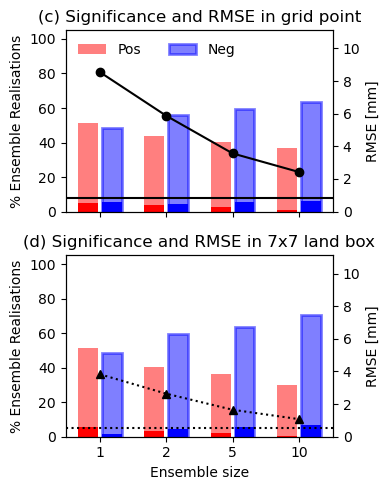

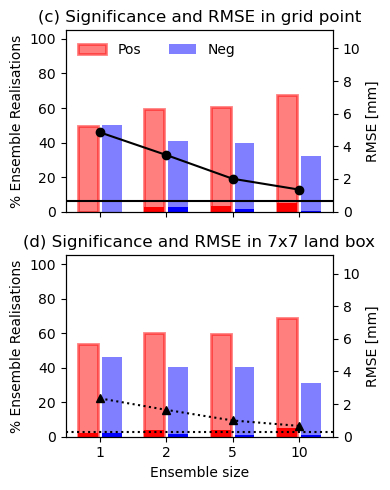

In [141]:
signs = ["Pos", "Neg"]
sign_colors = ["red", "blue"]
regions = [f"(c) Significance and RMSE in grid point", f"(d) Significance and RMSE in 7x7 land box"]
marker_reg = ["o", "^"]
lstyle_reg = ["-", ":"]
ind_1 = 0
ind_2 = 1

for itown in range(no_towns):
    fig, axes = plt.subplots(2, 1, figsize=(4, 5), sharex=True)
    
    width = 0.3
    
    for ireg in range(2):
        
        ax = axes[ireg]
        ax2 = ax.twinx() # twin axis for RMSE
        
        for isign in range(2):
    
            x = np.arange(no_size-1) + (isign - 0.5) * width*1.2
            edgecolor = [sign_colors[isign] if (diff[itown,ireg]>0 and isign==0) or (diff[itown,ireg]<0 and isign==1) else "none"]

            # total fraction (pos/neg split)
            if edgecolor[0] != "none":
                ax.bar(x, frac_sign[isign, :, itown, ireg]*100, width=width,
                       label=signs[isign] if ireg == 0 else None, color=sign_colors[isign], alpha=.5,
                       edgecolor=edgecolor, linewidth=2)
            else:
                ax.bar(x, frac_sign[isign, :, itown, ireg]*100, width=width,
                       label=signs[isign] if ireg == 0 else None, color=sign_colors[isign], alpha=.5)
    
            # overlay significant fraction
            ax.bar(x, frac_significance[isign, :, itown, ireg]*100, width=width,
                   color=sign_colors[isign], alpha=1)
            
            
        # ---- RMSE line (example) ----
        x_center = np.arange(no_size-1)  # center of bars
        ax2.axhline(y=np.absolute(diff_pastpres[itown, ireg]), color='black', linestyle=lstyle_reg[ireg]) 
        ax2.plot(x_center, rmse_bysize[:, itown, ireg],
                 color='black', marker=marker_reg[ireg], label="RMSE", linestyle=lstyle_reg[ireg])
        
        # Set parameters
        ax.set_title(f"{regions[ireg]}", fontsize=12)
        ax.set_xticks(np.arange(no_size-1))
        ax.set_xticklabels(list_size_ens[:-1])
        ax.set_ylabel("% Ensemble Realisations")
        ax.set_ylim(0, 105)
        ax2.set_ylim(0, np.max(rmse_bysize)*1.3)
        ax2.set_ylabel("RMSE [mm]")
    
    axes[1].set_xlabel("Ensemble size")
    axes[0].legend(ncol=2, frameon=False, loc="upper left")
    
    plt.tight_layout()

    # Save the figure
    fig.savefig(f"{fig_dir}{varname}_significance-rmse_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{names_year_ranges[ind_1]}_{names_year_ranges[ind_2]}_CRCM5_{str_size_ens}.png", bbox_inches='tight', dpi=300)
    fig.savefig(f"{fig_dir}{varname}_significance-rmse_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_{names_year_ranges[ind_1]}_{names_year_ranges[ind_2]}_CRCM5_{str_size_ens}.pdf", bbox_inches='tight')

### Distribution of average precipitation in town mask

In [13]:
# Parameters
# Variable
varname = 'pr'
factor = 3600

# List epochs
list_year_ranges = [[1955, 1974], [2004, 2023], [2080, 2099]] # past [1955-1974], present [2004-2023], near-future [2030-2049], far future [2080-2099]
no_epochs = len(list_year_ranges)
list_epoch_names = ['PAST', 'PRESENT', 'FUTURE']

# Significance tests
stat_tests = ['CvM', 'tW']  # 'KS' for Kolmogorov-Smirnov test, tW for Welch's t-test, AD for Anderson-Darling test, CvM for Cramér-von Mises test
no_stat_tests = len(stat_tests)

# List of ensemble sizes (by no members considered)
list_size_ens = [1, 2, 5, 10, 49, 49]
str_size_ens = ''
for se in list_size_ens:
    str_size_ens += f'{se}-'
str_size_ens = str_size_ens[:-1] + 'membs'
print(str_size_ens)

# Towns
no_towns = len(town_names)
no_town_var = 3

1-2-5-10-49-49membs


In [120]:
# BAM regional mean precipitation
BAM_info, BAM_index = fanPM.get_best_model_analogue_info(no_node, no_event, var_BAM)
mean_pr_BAM_in_town_mask = BAM_info['precip_in_town_7x7_land_mask'][BAM_index]

# Upload analogue data for mean precipitation in BAM mask
no_size = len(list_size_ens)
list_pr_town = []  # List to store difference datasets
list_stats_past = []  # List to store statistics for past epochs
list_stats_future = []  # List to store statistics for future epochs
list_stats_pastfuture = []  # List to store statistics for past-future epochs
for i in range(no_size-1):
    no_memb = list_size_ens[i]
    for j in range(no_epochs):
        year_range = list_year_ranges[j]
        str_year_range = "-".join(str(x) for x in year_range)

        # Load analogue values
        pr_town_epoch = np.ones((no_membs, no_analogues, no_towns)) * np.nan
        for im, memb in enumerate(list_membs[:no_memb]):
            for itown in range(no_towns):
                file = f'{pr_mask_dir}towns/analogues-{var_analogues}_{town_names[itown]}-{varname}_{str_event_BAM}_{qtl_LE_str}_{str_year_range}_CRCM5_{memb}.nc'
                if not os.path.exists(file):
                    print(f'File {file} does not exist. Skipping epoch {j+1}.')
                    continue
                file_data = xr.open_dataset(file)['pr_town_7x7_land'].values
                pr_town_epoch[im, :len(file_data), itown] = file_data
        list_pr_town.append(pr_town_epoch)

    # Compute p-val using KS test
    arr_past_all = list_pr_town[-3].reshape((no_membs*no_analogues,no_towns))
    arr_present_all = list_pr_town[-2].reshape((no_membs*no_analogues,no_towns))
    arr_future_all = list_pr_town[-1].reshape((no_membs*no_analogues,no_towns))
    stats_past = np.ones((no_stat_tests,no_towns, 2)) * np.nan
    stats_future = np.ones((no_stat_tests,no_towns, 2)) * np.nan
    stats_pastfuture = np.ones((no_stat_tests,no_towns, 2)) * np.nan
    for itown in range(no_towns):
        arr_past = arr_past_all[:,itown]
        arr_past = arr_past[~np.isnan(arr_past)]
        arr_present = arr_present_all[:, itown]
        arr_present = arr_present[~np.isnan(arr_present)]
        arr_future = arr_future_all[:, itown]
        arr_future = arr_future[~np.isnan(arr_future)]
        for istat in range(no_stat_tests):
            stat, stat_func = fanPM.get_stat_test(stat_tests[istat])
            stats_past[istat,itown] = stat_func(arr_past, arr_present)
            stats_future[istat,itown] = stat_func(arr_present, arr_future)
            stats_pastfuture[istat,itown] = stat_func(arr_past, arr_future)
    list_stats_past.append(stats_past)
    list_stats_future.append(stats_future)
    list_stats_pastfuture.append(stats_pastfuture)

list_pr_town.extend([pr_town[:,:2,:] for pr_town in list_pr_town[-3:]])
arr_past_2best = list_pr_town[-3].reshape((no_membs*2,no_towns))
arr_present_2best = list_pr_town[-2].reshape((no_membs*2,no_towns))
arr_future_2best = list_pr_town[-1].reshape((no_membs*2,no_towns))
stats_past = np.ones((no_stat_tests,no_towns, 2)) * np.nan
stats_future = np.ones((no_stat_tests,no_towns, 2)) * np.nan
for itown in range(no_towns):
    arr_past = arr_past_2best[:,itown]
    arr_past = arr_past[~np.isnan(arr_past)]
    arr_present = arr_present_2best[:, itown]
    arr_present = arr_present[~np.isnan(arr_present)]
    arr_future = arr_future_2best[:, itown]
    arr_future = arr_future[~np.isnan(arr_future)]
    for istat in range(no_stat_tests):
        stat, stat_func = fanPM.get_stat_test(stat_tests[istat])
        stats_past[istat,itown] = stat_func(arr_past, arr_present)
        stats_future[istat,itown] = stat_func(arr_present, arr_future)
        stats_pastfuture[istat,itown] = stat_func(arr_past, arr_future)
list_stats_past.append(stats_past)
list_stats_future.append(stats_future)
list_stats_pastfuture.append(stats_pastfuture)

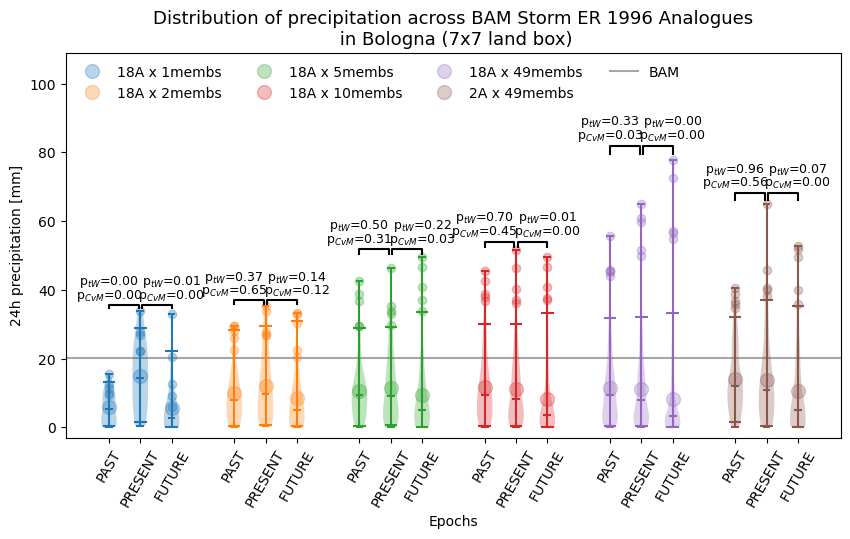

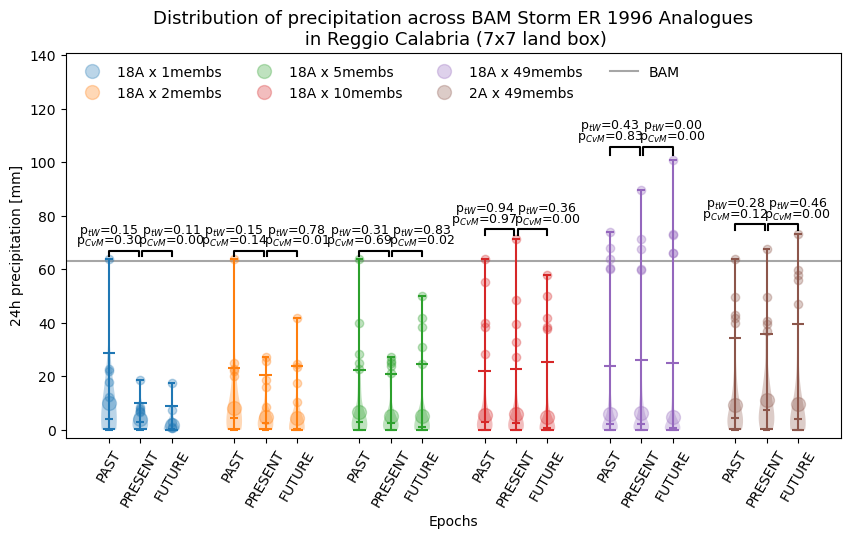

In [121]:
# Plot violin plots per epoch, once per ensemble size.
# Repeat for both towns
event_name = fanPM.get_storm_name(no_node, no_event)

for itown in range(no_towns):

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    #fig.suptitle(f"Precipitation in BAM {event_name} Analogues", fontsize=14)
    ax.set_title(f"Distribution of precipitation across BAM {event_name} Analogues\n in {town_names[itown]} (7x7 land box)", fontsize=13)

    # Violin plot setup
    list_epoch_str = [f"{year_range[0]}-{year_range[1]}" for year_range in list_year_ranges]
    
    for i in range(no_size):
        # Get the data for the current epoch and ensemble size
        list_town_precip =  [x[:,:,itown] for x in list_pr_town[i*no_epochs:(i+1)*no_epochs]]
        # Plot the violin for the current epoch and ensemble size
        town_precip_clean = [x[~np.isnan(x)]*factor for x in list_town_precip]
        violin = ax.violinplot(town_precip_clean, positions=1+i*4+np.arange(no_epochs),showmeans=False, showmedians=True, showextrema=True)
        # Plot the mean precipitation for the epoch
        violin_color = violin['bodies'][0].get_facecolor().flatten()
        no_memb = list_size_ens[i]
        if i < no_size - 1:
            plot_label = f'18A x {no_memb}membs'
        else:
            plot_label = f'2A x {no_memb}membs'
        ax.plot(1+i*4+np.arange(no_epochs), [np.mean(town_precip_clean[j]) for j in range(len(town_precip_clean))], marker='o', color=violin_color, markersize=10, label=plot_label, linewidth=0)
        
        for j in range(no_epochs):
            # Plot the 5 top values as small circles
            top5_values = np.sort(town_precip_clean[j])[-5:]
            ax.plot(np.full(top5_values.shape, 1 + i*4 + j), top5_values, marker='o', color=violin_color, markersize=6, linewidth=0)
            # Plot 5 and 95 percentiles
            p5, p95 = np.percentile(town_precip_clean[j], [5, 95])
            ax.hlines([p5, p95], xmin=1 + i*4 + j -0.2, xmax=1 + i*4 + j + 0.2, colors=violin_color, alpha=1)
        
        # Get x positions of the two violins
        x1 = 1 + i*4 + 0              # first violin position
        x2a = 1 + i*4 + 0.95              # second violin position
        x2b = 1 + i*4 + 1.05
        x3 = 1 + i*4 + 2              # third violin position
        y_max = max([np.max(town_precip_clean[j]) for j in range(no_epochs)]) 
        if i == no_size - 2:
            y_max_abs = y_max  # highest point for vertical placement
        # Draw a bracket line
        ax.plot([x1, x1, x2a, x2a], [y_max*1.02, y_max*1.05, y_max*1.05, y_max*1.02], color="black")
        ax.plot([x2b, x2b, x3, x3], [y_max*1.02, y_max*1.05, y_max*1.05, y_max*1.02], color="black")
        # Add p-value
        for istat in range(no_stat_tests):
            stat_name = stat_tests[istat]
            p_past = list_stats_past[i][istat,itown,1]
            p_future = list_stats_future[i][istat,itown,1]
            ax.text(x1, y_max*1.06+istat*4, f"p$_{{{stat_name}}}$={p_past:.2f}", ha="center", va="bottom", fontsize=9, color="black")
            ax.text(x3, y_max*1.06+istat*4, f"p$_{{{stat_name}}}$={p_future:.2f}", ha="center", va="bottom", fontsize=9, color="black")

    # Plot the mean precipitation of the BAM event
    ax.axhline(mean_pr_BAM_in_town_mask[itown], color='grey', linestyle='-', label='BAM', alpha=0.7, zorder=0)
    # Ticks and labels
    ax.set_xticks(range(1, no_size*(no_epochs + 1)))
    list_epoch_ticks = []
    xticks = []
    for i in range(no_size):
        xticks.extend([1+i*4+j for j in range(no_epochs)])
        list_epoch_ticks.extend(list_epoch_names)
    ax.set_ylim(-3,np.max((mean_pr_BAM_in_town_mask[itown],y_max_abs))*1.4)
    ax.set_xticks(xticks)
    ax.set_xticklabels(list_epoch_ticks, rotation=60)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('24h precipitation [mm]')
    ax.legend(ncol=4, frameon=False, loc='upper left') 
    plt.show()
    
    # Save the figure
    fig.savefig(f"{fig_dir}{varname}_mask-mean_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_CRCM5_{str_size_ens}.png", bbox_inches='tight', dpi=300)
    fig.savefig(f"{fig_dir}{varname}_mask-mean_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_CRCM5_{str_size_ens}.pdf", bbox_inches='tight')

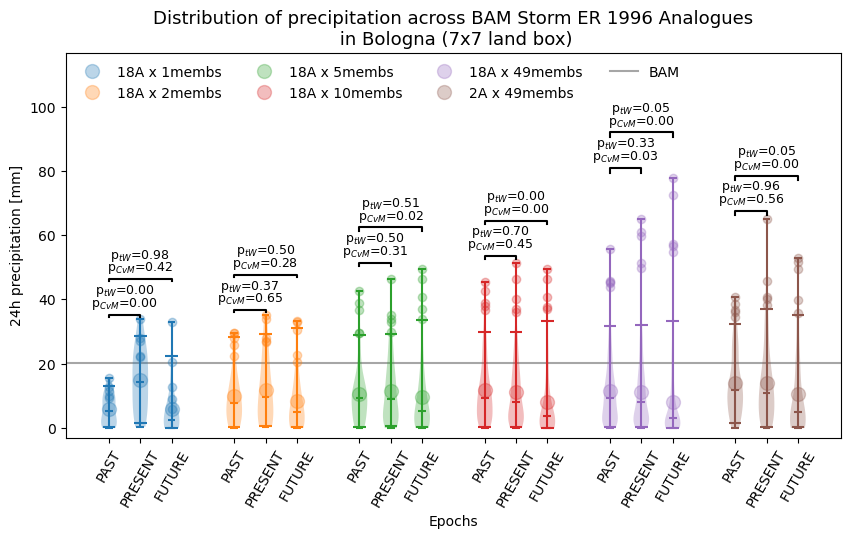

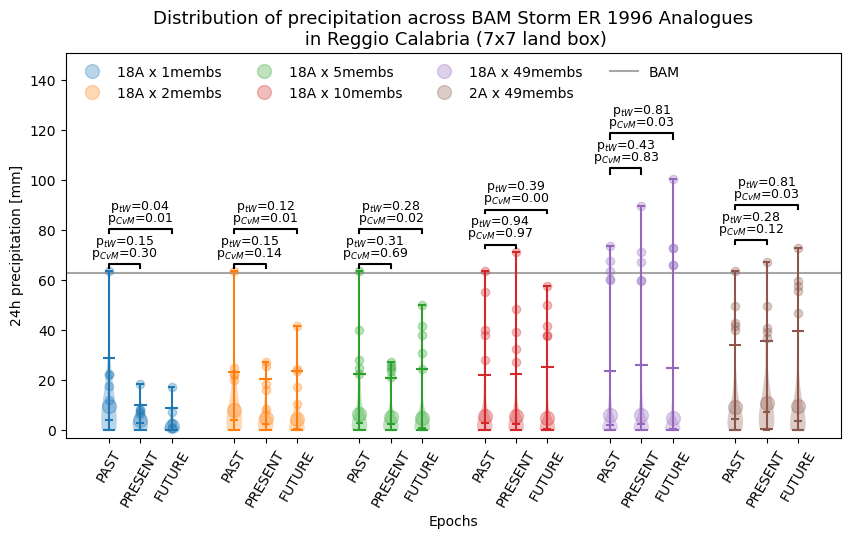

In [ ]:
# Plot violin plots per epoch, once per ensemble size.
# Repeat for both towns
event_name = fanPM.get_storm_name(no_node, no_event)

for itown in range(no_towns):

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    # fig.suptitle(f"Precipitation in BAM {event_name} Analogues: Sensitivity to Ensemble Size and Domain", fontsize=14)
    ax.set_title(f"Distribution of precipitation across BAM {event_name} Analogues\n in {town_names[itown]} (7x7 land box)", fontsize=13)

    # Violin plot setup
    list_epoch_str = [f"{year_range[0]}-{year_range[1]}" for year_range in list_year_ranges]
    
    for i in range(no_size):
        # Get the data for the current epoch and ensemble size
        list_town_precip =  [x[:,:,itown] for x in list_pr_town[i*no_epochs:(i+1)*no_epochs]]
        # Plot the violin for the current epoch and ensemble size
        town_precip_clean = [x[~np.isnan(x)]*factor for x in list_town_precip]
        violin = ax.violinplot(town_precip_clean, positions=1+i*4+np.arange(no_epochs),showmeans=False, showmedians=True, showextrema=True)
        # Plot the mean precipitation for the epoch
        violin_color = violin['bodies'][0].get_facecolor().flatten()
        no_memb = list_size_ens[i]
        if i < no_size - 1:
            plot_label = f'18A x {no_memb}membs'
        else:
            plot_label = f'2A x {no_memb}membs'
        ax.plot(1+i*4+np.arange(no_epochs), [np.mean(town_precip_clean[j]) for j in range(len(town_precip_clean))], marker='o', color=violin_color, markersize=10, label=plot_label, linewidth=0)
        
        for j in range(no_epochs):
            # Plot the 5 top values as small circles
            top5_values = np.sort(town_precip_clean[j])[-5:]
            ax.plot(np.full(top5_values.shape, 1 + i*4 + j), top5_values, marker='o', color=violin_color, markersize=6, linewidth=0)
            # Plot 5 and 95 percentiles
            p5, p95 = np.percentile(town_precip_clean[j], [5, 95])
            ax.hlines([p5, p95], xmin=1 + i*4 + j -0.2, xmax=1 + i*4 + j + 0.2, colors=violin_color, alpha=1)
        
        # Get x positions of the two violins
        x1 = 1 + i*4 + 0              # first violin position
        x2 = 1 + i*4 + 1              # second violin position
        x3 = 1 + i*4 + 2              # third violin position
        y_max = max([np.max(town_precip_clean[j]) for j in range(no_epochs)]) 
        if i == no_size - 2:
            y_max_abs = y_max  # highest point for vertical placement
        # Draw a bracket line
        y_sep = 11
        y_sep_text = 1
        y_sep_fact = 4
        ax.plot([x1, x1, x2, x2], [y_max*1.02, y_max*1.04, y_max*1.04, y_max*1.02], color="black")
        ax.plot([x1, x1, x3, x3], [y_max*1.02+y_sep, y_max*1.04+y_sep, y_max*1.04+y_sep, y_max*1.02+y_sep], color="black")
        # Add p-value
        for istat in range(no_stat_tests):
            stat_name = stat_tests[istat]
            p_past = list_stats_past[i][istat,itown,1]
            p_pastfuture = list_stats_pastfuture[i][istat,itown,1]
            ax.text((x1+x2)/2, y_max*1.04+y_sep_text+istat*y_sep_fact, f"p$_{{{stat_name}}}$={p_past:.2f}", ha="center", va="bottom", fontsize=9, color="black")
            ax.text((x1+x3)/2, y_max*1.04+y_sep+y_sep_text+istat*y_sep_fact, f"p$_{{{stat_name}}}$={p_pastfuture:.2f}", ha="center", va="bottom", fontsize=9, color="black")

    # Plot the mean precipitation of the BAM event
    ax.axhline(mean_pr_BAM_in_town_mask[itown], color='grey', linestyle='-', label='BAM', alpha=.7, zorder=0)
    # Ticks and labels
    ax.set_xticks(range(1, no_size*(no_epochs + 1)))
    list_epoch_ticks = []
    xticks = []
    for i in range(no_size):
        xticks.extend([1+i*4+j for j in range(no_epochs)])
        list_epoch_ticks.extend(list_epoch_names)
    ax.set_ylim(-3,np.max((mean_pr_BAM_in_town_mask[itown],y_max_abs))*1.5)
    ax.set_xticks(xticks)
    ax.set_xticklabels(list_epoch_ticks, rotation=60)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('24h precipitation [mm]')
    ax.legend(ncol=4, frameon=False, loc='upper left') 
    plt.show()
    
    # Save the figure
    fig.savefig(f"{fig_dir}{varname}_mask-mean_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_PAST-FUTURE_CRCM5_{str_size_ens}.png", bbox_inches='tight', dpi=300)
    fig.savefig(f"{fig_dir}{varname}_mask-mean_{town_names[itown]}_analogues-{var_analogues}_{str_event_BAM}_{qtl_LE_str}_PAST-FUTURE_CRCM5_{str_size_ens}.pdf", bbox_inches='tight')